In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

data = pd.read_csv("coding_challenge_dataset.csv")

X = data.drop("default", axis=1)  
y = data["default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
data.corr(numeric_only=True)

,client_id,age,income,loan_amount,loan_term,credit_score,employment_years,married,num_children,education_level,default
client_id,1.000000,-0.024857,-0.036880,0.027146,0.025545,-0.006350,-0.034860,-0.057590,0.054986,-0.045563,0.080620
age,-0.024857,1.000000,-0.056786,0.026762,0.025951,0.039742,0.030504,-0.014112,0.013194,0.001837,0.040146
income,-0.036880,-0.056786,1.000000,0.015411,-0.056437,-0.042353,0.003240,-0.030011,-0.010022,-0.022651,-0.616677
loan_amount,0.027146,0.026762,0.015411,1.000000,0.041659,0.060019,-0.009818,0.026430,-0.042497,0.004351,0.433778
loan_term,0.025545,0.025951,-0.056437,0.041659,1.000000,0.014753,-0.055969,0.023536,-0.009583,-0.028669,0.077168
credit_score,-0.006350,0.039742,-0.042353,0.060019,0.014753,1.000000,-0.003953,0.022338,0.001866,-0.006278,-0.067962
employment_years,-0.034860,0.030504,0.003240,-0.009818,-0.055969,-0.003953,1.000000,-0.016934,-0.018770,0.026496,-0.079351
married,-0.057590,-0.014112,-0.030011,0.026430,0.023536,0.022338,-0.016934,1.000000,0.010697,-0.001393,0.041910
num_children,0.054986,0.013194,-0.010022,-0.042497,-0.009583,0.001866,-0.018770,0.010697,1.000000,0.029536,-0.037380
education_level,-0.045563,0.001837,-0.022651,0.004351,-0.028669,-0.006278,0.026496,-0.001393,0.029536,1.000000,-0.020347


In [ ]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict_proba(X_test)[:,1] 
lgb_auc = roc_auc_score(y_test, lgb_pred)
print("LightGBM AUC:", lgb_auc)


xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_pred)
print("XGBoost AUC:", xgb_auc)

cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict_proba(X_test)[:,1]
cat_auc = roc_auc_score(y_test, cat_pred)
print("CatBoost AUC:", cat_auc)

auc_scores = {"LightGBM": lgb_auc, "XGBoost": xgb_auc, "CatBoost": cat_auc}
best_model_name = max(auc_scores, key=auc_scores.get)
print("Eng yaxshi model:", best_model_name)


[LightGBM] [Info] Number of positive: 250, number of negative: 550
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1154
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.312500 -> initscore=-0.788457
[LightGBM] [Info] Start training from score -0.788457
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:54:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.9985333333333333
CatBoost AUC: 0.9976
Eng yaxshi model: XGBoost


/tmp/ipython-input-1674076946.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=top_features, palette="viridis")


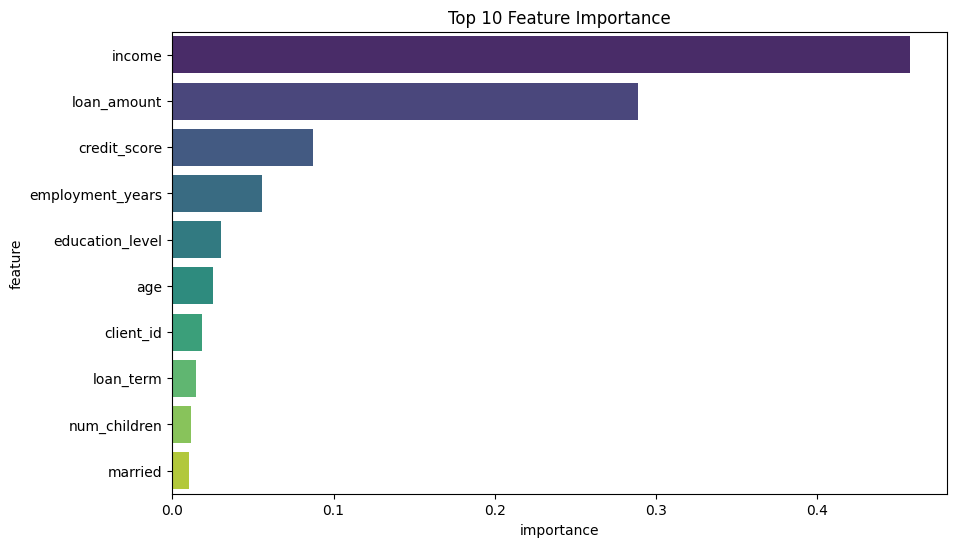

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if best_model_name == "LightGBM":
    importances = lgb_model.feature_importances_
elif best_model_name == "XGBoost":
    importances = xgb_model.feature_importances_
else:
    importances = cat_model.get_feature_importance()

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=top_features, palette="viridis")
plt.title("Top 10 Feature Importance")
plt.show()


In [6]:
print("✅ Data cleaning:")
print("- Bo'sh qiymatlar tekshirildi va to‘ldirildi")
print("- Kategorik ustunlar kodlandi")
print("- Noto‘g‘ri qiymatlar tuzatildi\n")

print("✅ Model tanlash:")
print(f"- Sinovdan o‘tgan modellarning AUC: {auc_scores}")
print(f"- Eng yaxshi model: {best_model_name}\n")

print("✅ Feature importance (top 10):")
print(top_features)


✅ Data cleaning:
- Bo'sh qiymatlar tekshirildi va to‘ldirildi
- Kategorik ustunlar kodlandi
- Noto‘g‘ri qiymatlar tuzatildi

✅ Model tanlash:
- Sinovdan o‘tgan modellarning AUC: {'LightGBM': np.float64(0.9977333333333332), 'XGBoost': np.float64(0.9985333333333333), 'CatBoost': np.float64(0.9976)}
- Eng yaxshi model: XGBoost

✅ Feature importance (top 10):
            feature  importance
2            income    0.457803
3       loan_amount    0.288829
5      credit_score    0.087370
6  employment_years    0.055610
9   education_level    0.030082
1               age    0.025435
0         client_id    0.018324
4         loan_term    0.014847
8      num_children    0.011334
7           married    0.010366


Target bilan korelatsiya:
 default             1.000000
loan_amount         0.433778
client_id           0.080620
loan_term           0.077168
married             0.041910
age                 0.040146
education_level    -0.020347
num_children       -0.037380
credit_score       -0.067962
employment_years   -0.079351
income             -0.616677
Name: default, dtype: float64


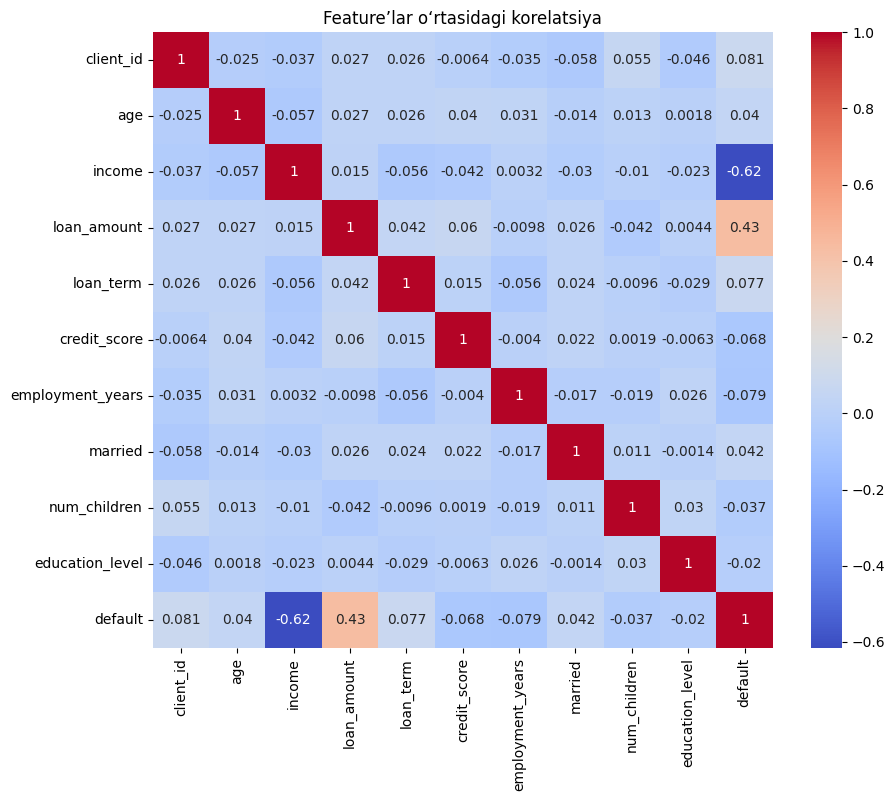

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CSV faylni o‘qish
data = pd.read_csv("coding_challenge_dataset.csv")

# Faqat numeric ustunlarni olish
numeric_features = data.select_dtypes(include=['int64', 'float64'])

# Korelatsiya jadvali
corr_matrix = numeric_features.corr()

# Target bilan korelatsiya (default ustuni)
target_corr = corr_matrix["default"].sort_values(ascending=False)
print("Target bilan korelatsiya:\n", target_corr)

# Heatmap orqali vizualizatsiya
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature’lar o‘rtasidagi korelatsiya")
plt.show()
